<a href="https://colab.research.google.com/github/Tahsin22201243/Machine-Learning/blob/main/MegaQuizSetA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np


In [3]:
df = pd.read_csv('/ecommerce_data.csv')

In [5]:
# 1. Identify column
col = 'last_purchase_days'


In [6]:


# 2. Replace values > 365 with median of valid values
valid_median = df[df[col] <= 365][col].median()
df[col] = np.where(df[col] > 365, valid_median, df[col])

# 3. Clip engagement_score (assume range 0–100)
df['engagement_score'] = np.clip(df['engagement_score'], 0, 100)

# 4. Show first 5 rows & count modified
modified_count = np.sum(df[col] == valid_median)

print(df.head())
print("Modified values:", modified_count)

   user_id  age        city  engagement_score  last_purchase_days  \
0        1   56      Sylhet         17.052460               168.0   
1        2   46  Chittagong         80.610815               273.0   
2        3   32      Sylhet         42.697326               231.0   
3        4   25      Sylhet         97.226353                86.0   
4        5   38      Khulna         68.736970               168.0   

   visits_per_month  avg_order_value  total_spend  is_premium  
0                33            46.32      1509.02           1  
1                25            63.16       959.60           1  
2                17            92.64      1686.83           1  
3                33            47.53      1030.67           1  
4                 2            97.38       127.89           0  
Modified values: 45


In [7]:
# Create user_tier column
def tier(x):
    if x > 500:
        return "Gold"
    elif 200 <= x <= 500:
        return "Silver"
    else:
        return "Bronze"

df['user_tier'] = df['total_spend'].apply(tier)

# Ordinal Encoding
mapping = {"Gold": 3, "Silver": 2, "Bronze": 1}
df['user_tier_encoded'] = df['user_tier'].map(mapping)

# Value counts
print(df['user_tier_encoded'].value_counts())

user_tier_encoded
3    147
2     32
1     26
Name: count, dtype: int64


In [8]:
# 1. Remove duplicates
df = df.drop_duplicates()

# 2. Fill missing city with mode
df['city'] = df['city'].fillna(df['city'].mode()[0])

# 3. Final shape
print(df.shape)

(200, 11)


In [9]:
grouped = df.groupby('is_premium')['total_spend']

summary = grouped.agg([
    'mean',
    'std',
    lambda x: np.percentile(x, 90)
])

summary.columns = ['Mean', 'Std Dev', '90th Percentile']

print(summary)


                   Mean      Std Dev  90th Percentile
is_premium                                           
0            235.790517   134.177741          422.861
1           1938.489648  1203.108031         3764.793


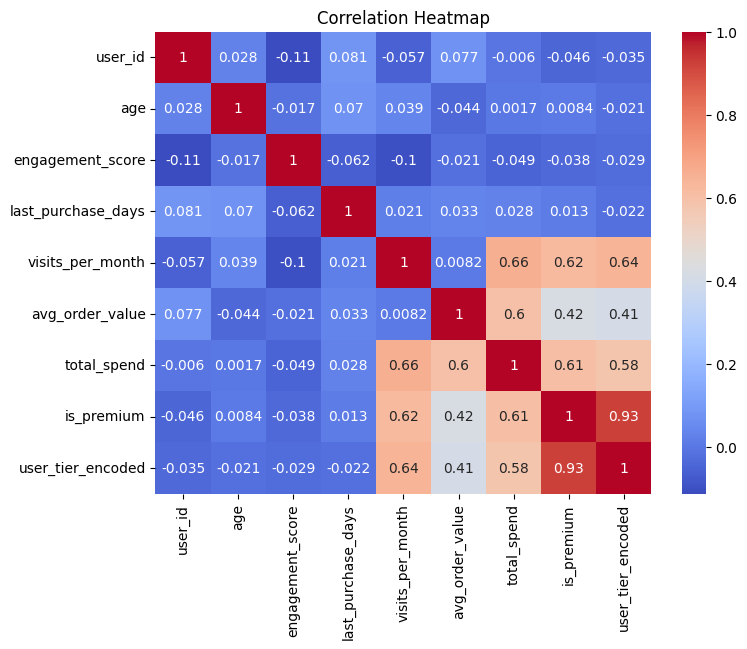

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features & target
X = df.drop(columns=['is_premium'])
y = df['is_premium']

# Convert categorical if needed
X = pd.get_dummies(X, drop_first=True)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X.head())


   user_id  age  engagement_score  last_purchase_days  visits_per_month  \
0        1   56         17.052460               168.0                33   
1        2   46         80.610815               273.0                25   
2        3   32         42.697326               231.0                17   
3        4   25         97.226353                86.0                33   
4        5   38         68.736970               168.0                 2   

   avg_order_value  total_spend  user_tier_encoded  city_Dhaka  city_Khulna  \
0            46.32      1509.02                  3       False        False   
1            63.16       959.60                  3       False        False   
2            92.64      1686.83                  3       False        False   
3            47.53      1030.67                  3       False        False   
4            97.38       127.89                  1       False         True   

   city_Rajshahi  city_Sylhet  user_tier_Gold  user_tier_Silver  
0       

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42
)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Confusion Matrix
print(confusion_matrix(y_test, y_pred))

# Classification Report
print(classification_report(y_test, y_pred))

[[20  0]
 [ 0 30]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        30

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50

